In [2]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


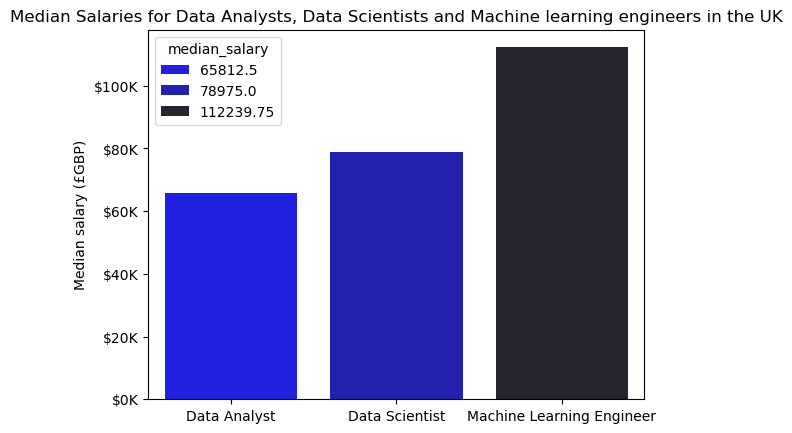

In [3]:

df_UK = df[(df['job_title_short'].isin(['Machine Learning Engineer', 'Data Analyst', 'Data Scientist']))&
            (df['job_country'] == 'United Kingdom')].dropna(subset = ['salary_year_avg'])

df_UK['salary_year_avg'] = df_UK['salary_year_avg']*0.75

df_UK_group = (
    df_UK.groupby('job_title_short')['salary_year_avg']
                .median()
                .reset_index(name = 'median_salary')                
)

sns.barplot(data = df_UK_group,
             x = 'job_title_short',
               y = 'median_salary',
                   palette = 'dark:b_r',
                   hue = 'median_salary')
plt.xlabel('')
plt.ylabel('Median salary (£GBP)')
plt.title('Median Salaries for Data Analysts, Data Scientists and Machine learning engineers in the UK')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

plt.show()